There are multiple lenses to look at food consumption and it's effects / correlations. You would expect some metrics to be
correlated and try to model from there.

Countries of interest for me here are Japan, France, UK, US, Germany owing to high availaibility but some specific analysis might need others.

# Supply of calories per person

This is not an actual consumption metric, but I would believe it to be highly correlated. Per capita, how much calories were available for consumption.

FAOSTAT changed its Food Balance methodology in 2010. The series below uses Our World in Data's combination of the old and new FAOSTAT datasets. Restricting it to 1961 onward keeps the source consistently FAOSTAT. The common period for all five countries is 1961–2022.

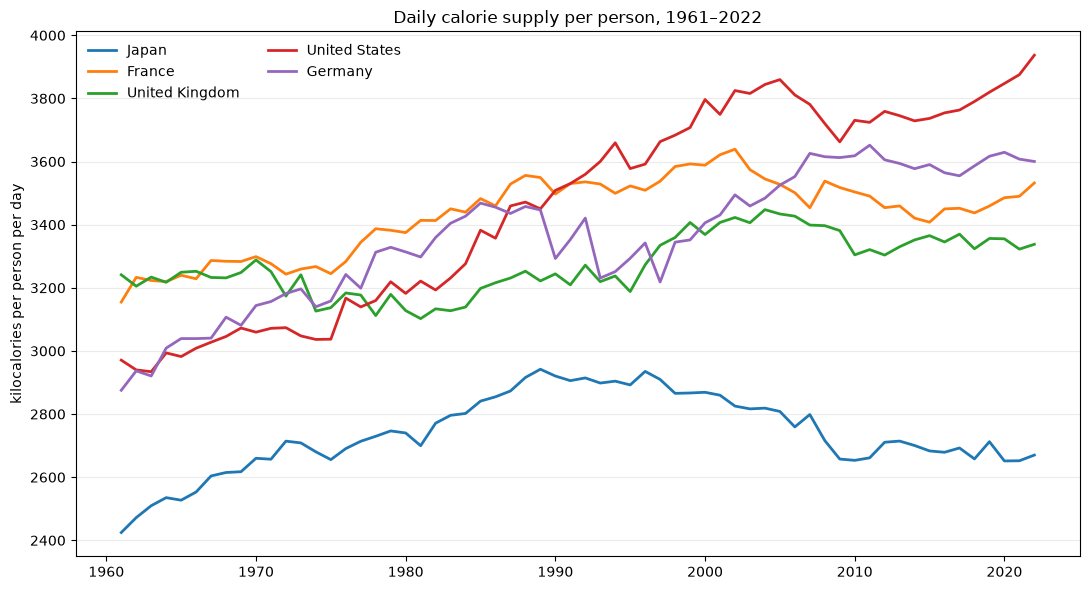

In [6]:
import matplotlib.pyplot as plt
import pandas as pd

countries = ["Japan", "France", "United Kingdom", "United States", "Germany"]
url = "https://ourworldindata.org/grapher/daily-per-capita-caloric-supply.csv?v=1&csvType=full&useColumnShortNames=false"

calories = pd.read_csv(
    url, storage_options={"User-Agent": "food-intake-analysis/0.1"}
)
calories = (
    calories.loc[calories["Entity"].isin(countries) & calories["Year"].ge(1961)]
    .pivot(index="Year", columns="Entity", values="Daily calorie supply per person")
    .dropna(subset=countries)
)
assert list(calories.columns.sort_values()) == sorted(countries)
assert calories.index.is_monotonic_increasing and not calories.empty

ax = calories[countries].plot(figsize=(11, 6), linewidth=2)
ax.set(
    title=f"Daily calorie supply per person, {calories.index.min()}–{calories.index.max()}",
    xlabel="",
    ylabel="kilocalories per person per day",
)
ax.grid(axis="y", alpha=0.25)
ax.legend(title=None, ncol=2, frameon=False)
plt.tight_layout()
plt.savefig("calorie-supply.png", dpi=180, bbox_inches="tight")
plt.show()

Japan once again an outlier, you could argue

# Obesity rates

France is an interesting case while I'm not at all surprised by Japan here.
Every country has such programmes and I cannot quite ascertain if it was indeed because of that but ChatGPT does refer to Programme National Nutrition Santé (PNNS)
as being one of the possible reasons.

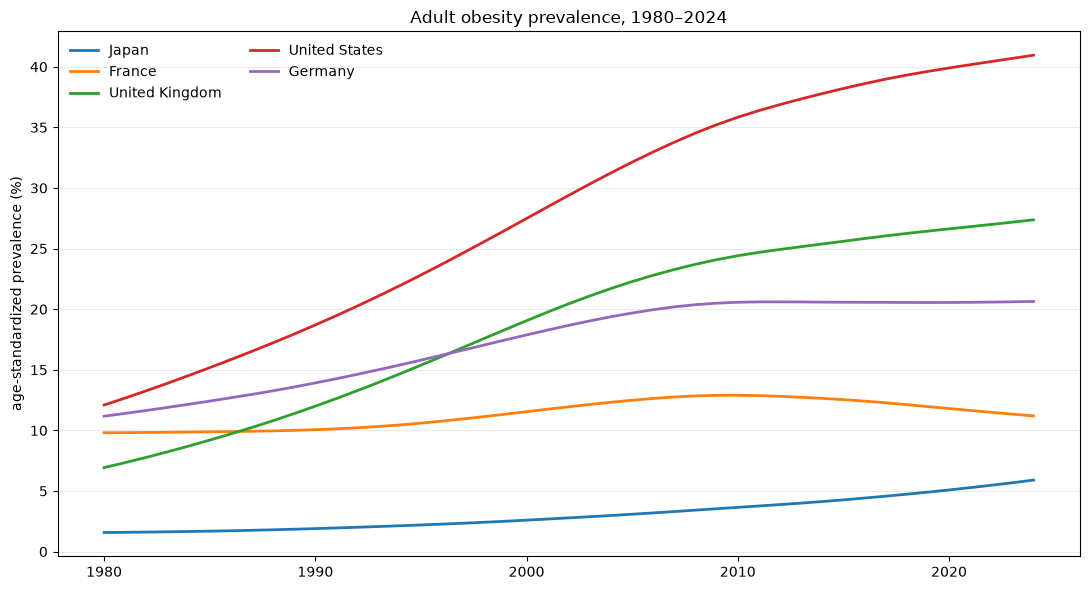

In [7]:
obesity_url = "https://ourworldindata.org/grapher/obesity-prevalence-adults-who-gho.csv?v=1&csvType=full&useColumnShortNames=false"
obesity_raw = pd.read_csv(
    obesity_url, storage_options={"User-Agent": "food-intake-analysis/0.1"}
)
obesity = (
    obesity_raw.loc[obesity_raw["Entity"].isin(countries)]
    .pivot(index="Year", columns="Entity", values=obesity_raw.columns[-1])
    .dropna(subset=countries)
)
assert list(obesity.columns.sort_values()) == sorted(countries)
assert obesity.index.is_monotonic_increasing and not obesity.empty

ax = obesity[countries].plot(figsize=(11, 6), linewidth=2)
ax.set(
    title=f"Adult obesity prevalence, {obesity.index.min()}–{obesity.index.max()}",
    xlabel="",
    ylabel="age-standardized prevalence (%)",
)
ax.grid(axis="y", alpha=0.25)
ax.legend(title=None, ncol=2, frameon=False)
plt.tight_layout()
plt.savefig("obesity-rates.png", dpi=180, bbox_inches="tight")
plt.show()

# Lagged correlation

To reduce correlation caused by both series trending over time, this compares annual changes rather than raw levels. Lag 0 compares changes in the same year; lag 5 compares a calorie-supply change with the obesity-rate change five years later. Pearson correlation does not establish causation.

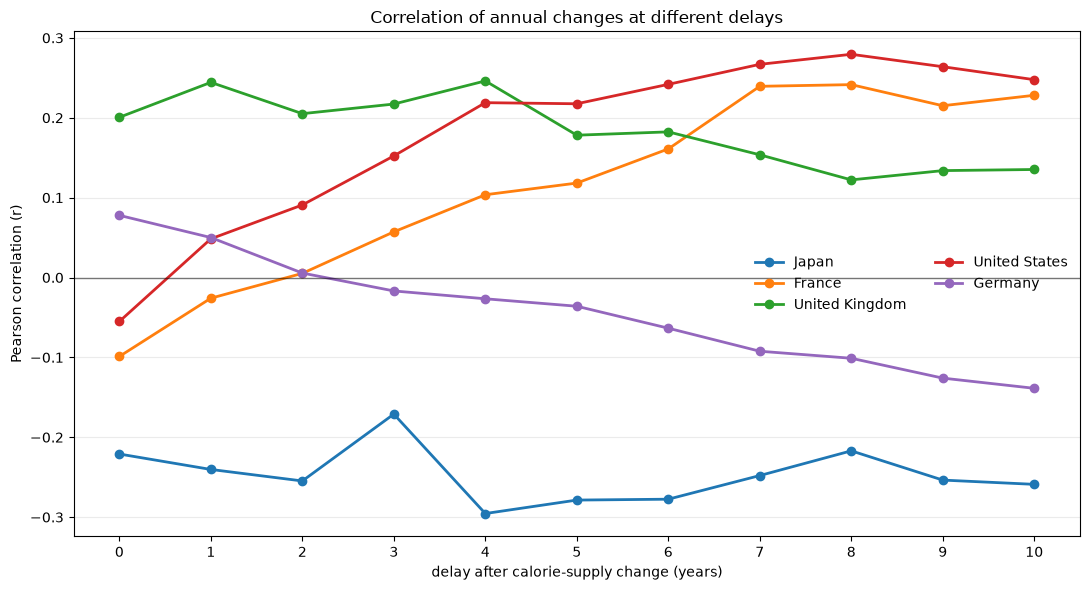

In [8]:
lag_years = range(11)
calorie_changes = calories.diff()
obesity_changes = obesity.diff()
lag_correlations = pd.DataFrame(
    {
        country: [
            calorie_changes[country].shift(lag).corr(obesity_changes[country])
            for lag in lag_years
        ]
        for country in countries
    },
    index=lag_years,
)
assert lag_correlations.notna().all().all()

ax = lag_correlations[countries].plot(figsize=(11, 6), marker="o", linewidth=2)
ax.axhline(0, color="black", linewidth=1, alpha=0.5)
ax.set(
    title="Correlation of annual changes at different delays",
    xlabel="delay after calorie-supply change (years)",
    ylabel="Pearson correlation (r)",
    xticks=list(lag_years),
)
ax.grid(axis="y", alpha=0.25)
ax.legend(title=None, ncol=2, frameon=False)
plt.tight_layout()
plt.savefig("lagged-correlations.png", dpi=180, bbox_inches="tight")
plt.show()

# Insufficient physical activity

WHO age-standardized estimates for adults aged 18 and over who do not meet recommended physical-activity levels. The estimates are based mainly on self-reported survey data and statistical modelling.

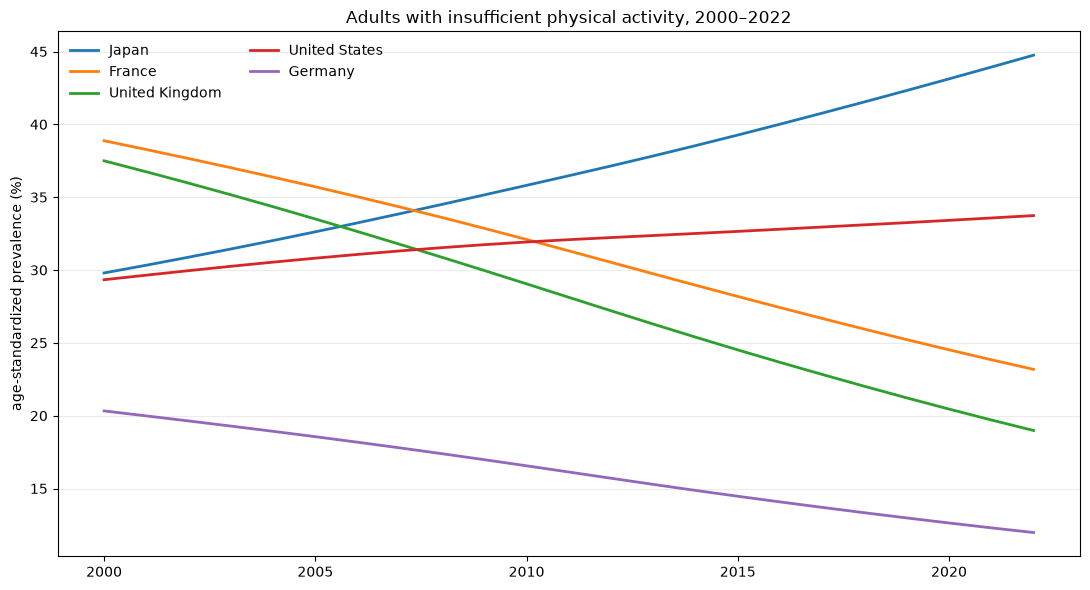

In [9]:
import json
from urllib.parse import urlencode
from urllib.request import Request, urlopen

country_codes = dict(zip(countries, ["JPN", "FRA", "GBR", "USA", "DEU"]))
activity_filter = " and ".join(
    [
        "Dim1 eq 'SEX_BTSX'",
        "Dim2 eq 'AGEGROUP_YEARS18-PLUS'",
        "(" + " or ".join(
            f"SpatialDim eq '{code}'" for code in country_codes.values()
        ) + ")",
    ]
)
activity_url = "https://ghoapi.azureedge.net/api/NCD_PAA?" + urlencode(
    {"$filter": activity_filter, "$select": "SpatialDim,TimeDim,NumericValue"}
)
with urlopen(Request(activity_url, headers={"User-Agent": "food-intake-analysis/0.1"})) as response:
    activity_raw = pd.DataFrame(json.load(response)["value"])

activity = (
    activity_raw.pivot(index="TimeDim", columns="SpatialDim", values="NumericValue")
    .rename(columns={code: country for country, code in country_codes.items()})
    .dropna(subset=countries)
)
assert list(activity.columns.sort_values()) == sorted(countries)

ax = activity[countries].plot(figsize=(11, 6), linewidth=2)
ax.set(
    title=f"Adults with insufficient physical activity, {activity.index.min()}–{activity.index.max()}",
    xlabel="",
    ylabel="age-standardized prevalence (%)",
)
ax.grid(axis="y", alpha=0.25)
ax.legend(title=None, ncol=2, frameon=False)
plt.tight_layout()
plt.savefig("insufficient-physical-activity.png", dpi=180, bbox_inches="tight")
plt.show()

Seems EU is consistently falling, very likely because of work expectations where Japan is worse, followed by US and then EU has much better working hours so gives them enough time for other stuff

# Fat supply per person

FAOSTAT-derived average daily fat availability. Like calorie supply, this measures food reaching households rather than the amount ultimately consumed.

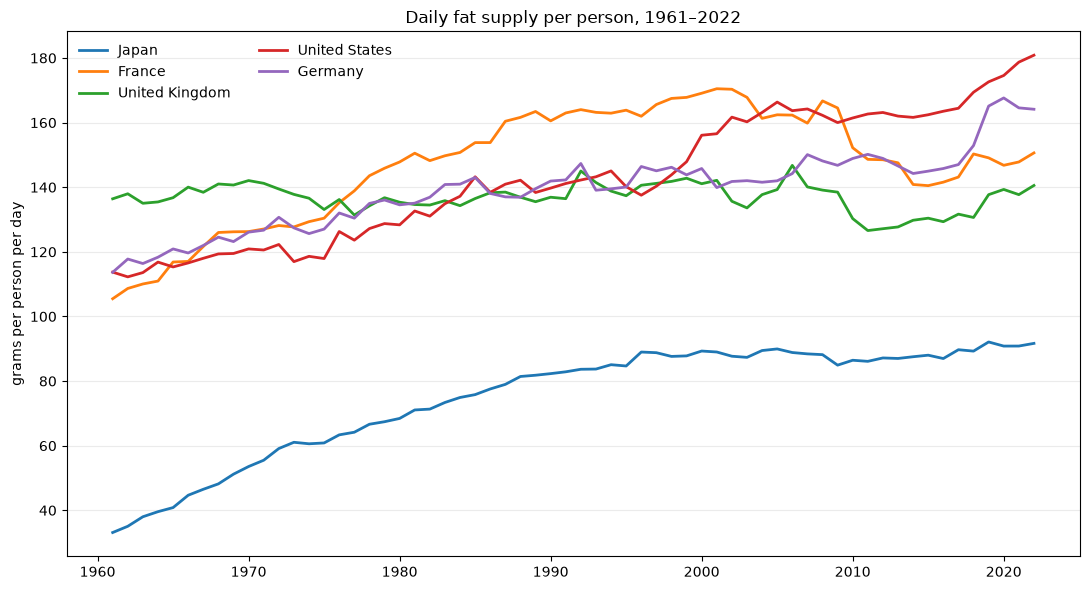

In [ ]:
fat_url = "https://ourworldindata.org/grapher/daily-per-capita-fat-supply.csv?v=1&csvType=full&useColumnShortNames=false"
fat_raw = pd.read_csv(
    fat_url, storage_options={"User-Agent": "food-intake-analysis/0.1"}
)
fat_supply = (
    fat_raw.loc[fat_raw["Entity"].isin(countries)]
    .pivot(index="Year", columns="Entity", values="Daily fat supply")
    .dropna(subset=countries)
)
assert list(fat_supply.columns.sort_values()) == sorted(countries)

ax = fat_supply[countries].plot(figsize=(11, 6), linewidth=2)
ax.set(
    title=f"Daily fat supply per person, {fat_supply.index.min()}-{fat_supply.index.max()}",
    xlabel="",
    ylabel="grams per person per day",
)
ax.grid(axis="y", alpha=0.25)
ax.legend(title=None, ncol=2, frameon=False)
plt.tight_layout()
plt.savefig("fat-supply.png", dpi=180, bbox_inches="tight")
plt.show()

# Measured energy expenditure

This is much closer to what I was looking for. [Speakman et al. (2023)](https://escholarship.org/uc/item/96w921s0) pulled together 4,799 measurements from adults in the US and Europe, taken between late 1981 and late 2017. Total energy expenditure (TEE) was measured using doubly labelled water, so it does not have the self-report problem of food surveys. For 1,432 measurements they also had basal energy expenditure (BEE). Activity energy expenditure (AEE) was worked out as `0.9 × TEE − BEE`, rather than measured directly.

After adjusting for age and body composition, these were the estimated changes over 30 years. I converted the figures from MJ to kcal.

| Component | Men | Women |
| --- | ---: | ---: |
| TEE | **−222 kcal/day** (−0.93 MJ/day; p < 0.0001) | **−122 kcal/day** (−0.51 MJ/day; p < 0.00002) |
| BEE | **−229 kcal/day** (−0.96 MJ/day; p < 10⁻⁹) | −29 kcal/day (−0.12 MJ/day; not significant) |
| AEE | **+241 kcal/day** (+1.01 MJ/day; p < 0.0003) | **+100 kcal/day** (+0.42 MJ/day; p = 0.026) |

This complicates the easy story that obesity rose because people became less active. Activity-related calorie burn went up in this dataset, while resting expenditure fell sharply for men. The fall in women's resting expenditure was small enough that it could just be noise. This does not necessarily mean people spent more time moving. Moving a heavier body costs more energy. It does mean that lower activity expenditure does not explain the fall in adjusted TEE here.

For food intake, the inference I can make is narrower. If people's energy needs fell and their intake did not fall by the same amount, gaining weight would become easier. The study did not measure intake, though, so it cannot tell me whether people ate less, more or about the same. It also compared different people and studies across time instead of following the same people for decades. So a slower metabolism is nother variable at play.